In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# Converting .csv files

In [6]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items') # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Sriram@2004',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/SRIRAM/OneDrive/Desktop/E-commerce/Dataset'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
prod

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host="localhost",
                             username = "root",
                             password = "Sriram@2004",
                             database = "ecommerce")

cur = db.cursor()

# 1. List all unique cities where customers are located.

In [9]:
query = """ Select DISTINCT(customer_city) from customers; """

cur.execute(query)

data = cur.fetchall()

data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# 2. Count the number of orders placed in 2017.

In [16]:
query = """ SELECT COUNT(order_id) FROM orders WHERE YEAR(STR_TO_DATE(order_purchase_timestamp, '%m/%d/%Y %H:%i')) = 2017; """

cur.execute(query)

data = cur.fetchall()

data[0][0]

45101

In [ ]:
#The above answer is from Chatgpt as the direct YEAR() fucntion wasn't working because the datatype of the order_purchase_timestamp is in VARCHAR type
#The below is my approach

In [18]:
query = """ Select COUNT(*) from ecommerce.orders where order_purchase_timestamp LIKE "%2017%" ; """

cur.execute(query)

data = cur.fetchall()

data[0][0]
"Total orders placed in 2017 are", data[0][0]

('Total orders placed in 2017 are', 45101)

# 3. Find the total sales per category.

In [22]:
query = """ Select upper(p.product_category_name) category, ROUND(SUM(ps.payment_value),2) Sales from products p join order_items o 
            ON p.product_id = o.product_id JOIN payments ps ON ps.order_id = o.order_id group by category; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["category", "sales"])
df

,category,sales
0,PERFUMARIA,506738.66
1,MOVEIS_DECORACAO,1430176.39
2,TELEFONIA,486882.05
3,FASHION_BOLSAS_E_ACESSORIOS,218158.28
4,CAMA_MESA_BANHO,1712553.67
...,...,...
69,CDS_DVDS_MUSICAIS,1199.43
70,LA_CUISINE,2913.53
71,FASHION_ROUPA_INFANTO_JUVENIL,785.67
72,PC_GAMER,2174.43


# 4. Calculate the percentage of orders that were paid in installments.


In [26]:
query = """ Select (sum(case when payment_installments >= 1 then 1 else 0 end))/count(*) *100 from payments; """

cur.execute(query)

data = cur.fetchall()

data

[(Decimal('99.9981'),)]

In [25]:
#The above output means that almost all the customers are paying in installments.Here, we are considering 1 as an installment also
#if we did not consider 1 as an installment then it would be 49.4176 percent value.

# 5. Count the number of customers from each state. 

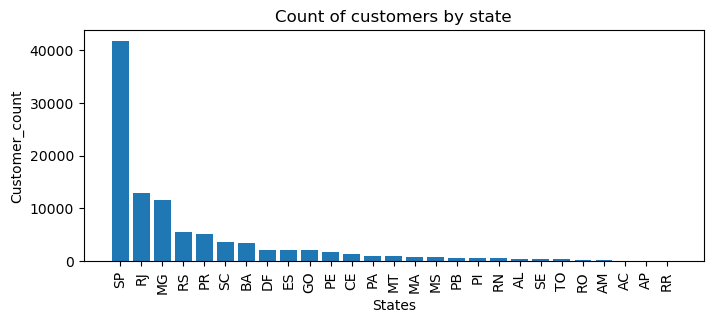

In [43]:
query = """ Select customer_state, COUNT(*) from customers group by customer_state; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["State", "Customer_count"])
df

#We can also visualize the data meanwhile for better understanding
df = df.sort_values(by = "Customer_count", ascending = False)
plt.figure(figsize=(8,3))
plt.bar(df['State'], df['Customer_count'])
plt.xticks(rotation=90) #The names of states are shown in vertical manner instead of horizontal in the chart label of x-axis which are xticks
plt.xlabel("States")
plt.ylabel("Customer_count")
plt.title("Count of customers by state")
plt.show()

# 6. Calculate the number of orders per month in 2018.

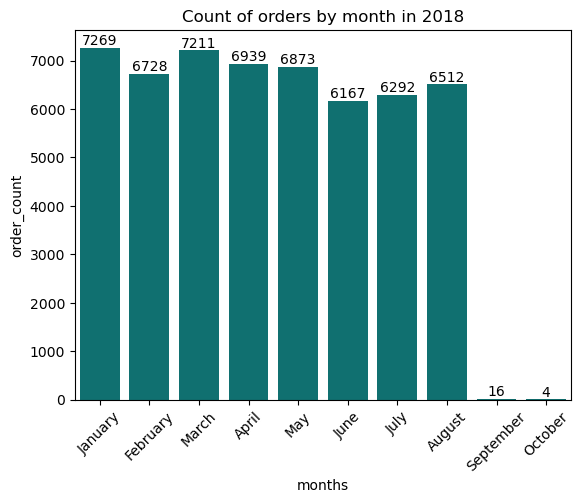

In [49]:
query = """ SELECT MONTHNAME(STR_TO_DATE(order_purchase_timestamp, '%m/%d/%Y %H:%i')) AS months, COUNT(order_id) AS order_count
            FROM Orders WHERE order_purchase_timestamp LIKE '%2018%' GROUP BY months ORDER BY months;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['months', 'order_count'])
#using seaborn here for plot
#set the order first
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]

ax = sns.barplot(x=df["months"], y=df["order_count"], data=df, order=o, color="teal")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0])#to show the values on the plot
plt.title("Count of orders by month in 2018")
plt.show()

# 7. Find the average number of products per order, grouped by customer city.

In [54]:
query = """ WITH step_one AS
            (Select oi.order_id, o.customer_id, COUNT(oi.product_id) as order_count from order_items oi JOIN orders o 
             ON oi.order_id = o.order_id GROUP BY oi.order_id, o.customer_id)

            Select c.customer_city, ROUND(AVG(so.order_count),2) avg_of_orders from customers c JOIN step_one so
            ON c.customer_id = so.customer_id GROUP BY c.customer_city order by avg_of_orders desc; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['customer_city','avg_products_per_order'])
df.head(10)

,customer_city,avg_products_per_order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


# 8. Calculate the percentage of total revenue contributed by each product category.

In [57]:
query = """ Select upper(p.product_category_name) category, ROUND((SUM(ps.payment_value)/(Select SUM(payment_value) from payments))*100,2) Sales
            from products p join order_items o ON p.product_id = o.product_id JOIN payments ps ON ps.order_id = o.order_id group by category 
            order by Sales desc; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Product_cat_name','Revenue in %'])
df

,Product_cat_name,Revenue in %
0,CAMA_MESA_BANHO,10.70
1,BELEZA_SAUDE,10.35
2,INFORMATICA_ACESSORIOS,9.90
3,MOVEIS_DECORACAO,8.93
4,RELOGIOS_PRESENTES,8.93
...,...,...
69,CASA_CONFORTO_2,0.01
70,CDS_DVDS_MUSICAIS,0.01
71,PC_GAMER,0.01
72,FASHION_ROUPA_INFANTO_JUVENIL,0.00


# 9. Identify the correlation between product price and the number of times a product has been purchased.

In [61]:
query = """ Select p.product_category_name,COUNT(oi.product_id), ROUND(AVG(oi.price),2) FROM products p JOIN order_items oi ON
            p.product_id = oi.product_id GROUP BY p.product_category_name; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['category','order_count','price'])
arr1 = df['order_count']
arr2 = df['price']

a = np.corrcoef([arr1,arr2])
print("The correlation between price and number of times the product has been purchase is: ", a[0][1])

The correlation between price and number of times the product has been purchase is:  -0.10631514167157562


# 10. Calculate the total revenue generated by each seller, and rank them by revenue.

In [62]:
query = """ WITH seller_revenue AS (
            SELECT oi.seller_id, ROUND(SUM(p.payment_value),2) AS revenue FROM payments p JOIN order_items oi ON p.order_id = oi.order_id
            GROUP BY oi.seller_id)
            SELECT *, DENSE_RANK() OVER(ORDER BY revenue DESC) AS rn FROM seller_revenue; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['seller_id','total_revenue','rank'])
df

,seller_id,total_revenue,rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.21,3076
3091,702835e4b785b67a084280efca355756,18.56,3077
3092,4965a7002cca77301c82d3f91b82e1a9,16.36,3078
3093,77128dec4bec4878c37ab7d6169d6f26,15.22,3079


# 11. Calculate the moving average of order values for each customer over their order history.

In [63]:
query = """select customer_id, order_purchase_timestamp, payment,
           avg(payment) over(partition by customer_id order by order_purchase_timestamp rows between 2 preceding and current row) as moving_avg
           from (select orders.customer_id, orders.order_purchase_timestamp, payments.payment_value as payment from payments join orders ON
           payments.order_id = orders.order_id) as a;  """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['customer_id','order_time','price','moving_average'])
df

,customer_id,order_time,price,moving_average
0,00012a2ce6f8dcda20d059ce98491703,11/14/2017 16:08,114.74,114.739998
1,000161a058600d5901f007fab4c27140,7/16/2017 9:40,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2/28/2017 11:06,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,8/16/2017 13:09,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,4/2/2018 13:42,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,3/29/2018 16:59,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,5/22/2018 13:36,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,6/13/2018 16:57,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,9/2/2017 11:53,45.50,45.500000


# 12. Calculate the cumulative sales per month for each year.

In [64]:
query = """Select years, months, payment,
           SUM(payment) OVER(order by years,months) Cumulative_sales from
           (select YEAR(STR_TO_DATE(o.order_purchase_timestamp, '%m/%d/%Y %H:%i')) as YEARS,
            MONTH(STR_TO_DATE(o.order_purchase_timestamp, '%m/%d/%Y %H:%i')) AS MONTHS,
            ROUND(SUM(p.payment_value),2) as payment from orders o JOIN payments p ON
            o.order_id = p.order_id 
            GROUP BY YEARS, MONTHS
            ORDER BY YEARS, MONTHS) as a;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['YEARS','MONTHS','PAYMENT',"CUMULATIVE_VALUE"])
df

,YEARS,MONTHS,PAYMENT,CUMULATIVE_VALUE
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 13.Calculate the year-over-year growth rate of total sales.

In [65]:
query = """WITH a AS(select YEAR(STR_TO_DATE(o.order_purchase_timestamp, '%m/%d/%Y %H:%i')) as YEARS,       
           ROUND(SUM(p.payment_value),2) as payment 
           from orders o JOIN payments p ON o.order_id = p.order_id 
           group by years order by years) 
           Select years, payment,
           LAG(payment,1) OVER(order by years) previous_year,
           ((payment-LAG(payment,1) OVER(order by years))/(LAG(payment,1) OVER(order by years))*100) as yoy_percentage_growth
           from a ;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['YEARS','PAYMENT','PREVIOUS_YEAR','YOY_PERCENTAGE_GROWTH'])
df

,YEARS,PAYMENT,PREVIOUS_YEAR,YOY_PERCENTAGE_GROWTH
0,2016,59362.34,NaN,NaN
1,2017,7249746.73,59362.34,12112.703761
2,2018,8699763.05,7249746.73,20.000924


# 14.Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [67]:
query = """
        WITH a AS(SELECT c.customer_id, MIN(str_to_date(o.order_purchase_timestamp, '%m/%d/%Y %H:%i')) as first_order
        FROM customers c JOIN orders o ON c.customer_id = o.customer_id GROUP BY c.customer_id),
        
        b as(Select a.customer_id, COUNT(DISTINCT(str_to_date(o.order_purchase_timestamp, '%m/%d/%Y %H:%i'))) as next_order
        FROM a JOIN orders o ON  o.customer_id = a.customer_id
        AND o.order_purchase_timestamp > first_order
        AND o.order_purchase_timestamp < DATE_ADD(first_order, interval 6 month)
        group by a.customer_id)
        
        Select 100* (COUNT( Distinct a.customer_id)/COUNT(Distinct b.customer_id)) FROM a LEFT JOIN b
        ON a.customer_id = b.customer_id    
        ;"""

cur.execute(query)

data = cur.fetchall()

data
# Since, there a no repeated customers in 6 months the value/output is NULL/None.

[(None,)]

# 15.Identify the top 3 customers who spent the most money in each year.

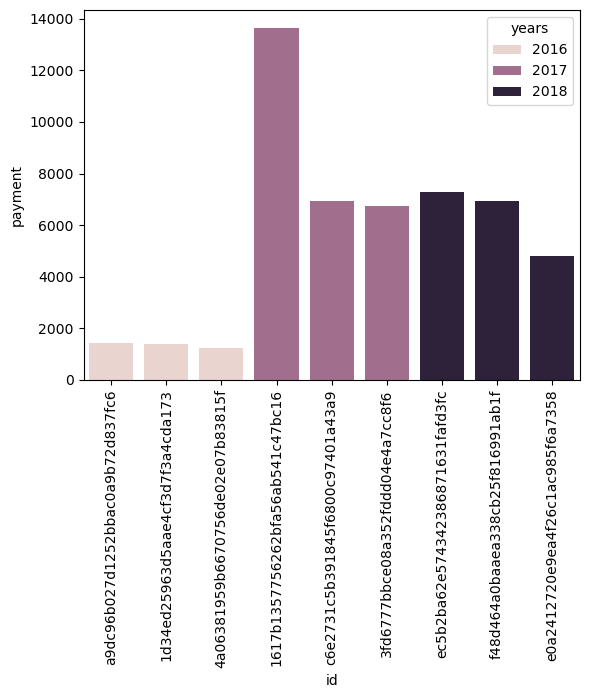

In [68]:
query = """Select years, customer_id, payment, d_rank from
           (Select YEAR(STR_TO_DATE(o.order_purchase_timestamp, '%m/%d/%Y %H:%i')) as YEARS,
           o.customer_id, SUM(p.payment_value) payment,
           dense_rank() OVER(partition by YEAR(STR_TO_DATE(o.order_purchase_timestamp, '%m/%d/%Y %H:%i'))
						     order by sum(p.payment_value) DESC) d_rank
           FROM orders o JOIN payments p 
           ON o.order_id = p.order_id 
           GROUP BY  YEAR(STR_TO_DATE(o.order_purchase_timestamp, '%m/%d/%Y %H:%i')), o.customer_id) as a where d_rank <= 3; """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['years', 'id', 'payment','rank'])
sns.barplot(x='id', y='payment', data=df, hue='years')
plt.xticks(rotation=90)
plt.show()